In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

df = pd.read_csv("data/salesdaily.csv")
df["datum"] = pd.to_datetime(df["datum"])

drug_columns = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

In [3]:
def forecast_drug(drug_name, df, test_size=30):
    """
    Trains ARIMA and Prophet on a drug category,
    compares RMSE, returns winner + metrics + forecasts.
    """

    arima_df = df.set_index("datum")[drug_name]
    arima_df.index.freq = "D"
    train_arima = arima_df[:-test_size]
    test_arima = arima_df[-test_size:]

    arima_model = ARIMA(train_arima, order=(2, 0, 2))
    arima_fit = arima_model.fit()
    arima_forecast = arima_fit.forecast(steps=test_size)
    arima_forecast.index = test_arima.index

    arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_forecast))

    prophet_df = df[["datum", drug_name]].rename(columns={"datum": "ds", drug_name: "y"})
    train_prophet = prophet_df[:-test_size]
    test_prophet = prophet_df[-test_size:]

    prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    prophet_model.fit(train_prophet)
    future = prophet_model.make_future_dataframe(periods=test_size)
    prophet_forecast = prophet_model.predict(future)["yhat"].tail(test_size).values

    prophet_rmse = np.sqrt(mean_squared_error(test_prophet["y"].values, prophet_forecast))

    if arima_rmse <= prophet_rmse:
        winner = "ARIMA"
        best_forecast = arima_forecast.values
        best_rmse = arima_rmse
    else:
        winner = "Prophet"
        best_forecast = prophet_forecast
        best_rmse = prophet_rmse
    return {
        "drug": drug_name,
        "arima_rmse": round(arima_rmse, 3),
        "prophet_rmse": round(prophet_rmse, 3),
        "winner": winner,
        "best_rmse": round(best_rmse, 3),
        "test_actual": test_arima.values,          
        "best_forecast": best_forecast,
        "test_dates": test_arima.index,
        "arima_model": arima_fit,
        "prophet_model": prophet_model
    }

In [4]:
results = []

for drug in drug_columns:
    print(f"Running forecast for {drug}...")
    result = forecast_drug(drug, df)
    results.append(result)

print("ALL DONE")

Running forecast for M01AB...


C:\Users\mukun\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\mukun\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
13:48:18 - cmdstanpy - INFO - Chain [1] start processing
13:48:18 - cmdstanpy - INFO - Chain [1] done processing


Running forecast for M01AE...


C:\Users\mukun\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
13:48:20 - cmdstanpy - INFO - Chain [1] start processing
13:48:20 - cmdstanpy - INFO - Chain [1] done processing


Running forecast for N02BA...


...

Running forecast for R03...


13:48:34 - cmdstanpy - INFO - Chain [1] start processing
13:48:34 - cmdstanpy - INFO - Chain [1] done processing


Running forecast for R06...


13:48:36 - cmdstanpy - INFO - Chain [1] start processing
13:48:36 - cmdstanpy - INFO - Chain [1] done processing


ALL DONE


In [5]:
summary = pd.DataFrame([{                           
    "Drug": r["drug"],
    "ARIMA RMSE": r["arima_rmse"],
    "Prophet RMSE": r["prophet_rmse"],
    "Winner": r["winner"],
    "Best RMSE": r["best_rmse"]
} for r in results])

print(summary.to_string(index=False))              

 Drug  ARIMA RMSE  Prophet RMSE  Winner  Best RMSE
M01AB       2.680         2.695   ARIMA      2.680
M01AE       2.085         1.938 Prophet      1.938
N02BA       1.637         1.759   ARIMA      1.637
N02BE      19.328        12.255 Prophet     12.255
 N05B       4.462         4.484   ARIMA      4.462
 N05C       1.020         1.033   ARIMA      1.020
  R03       6.138         7.319   ARIMA      6.138
  R06       2.122         1.995 Prophet      1.995


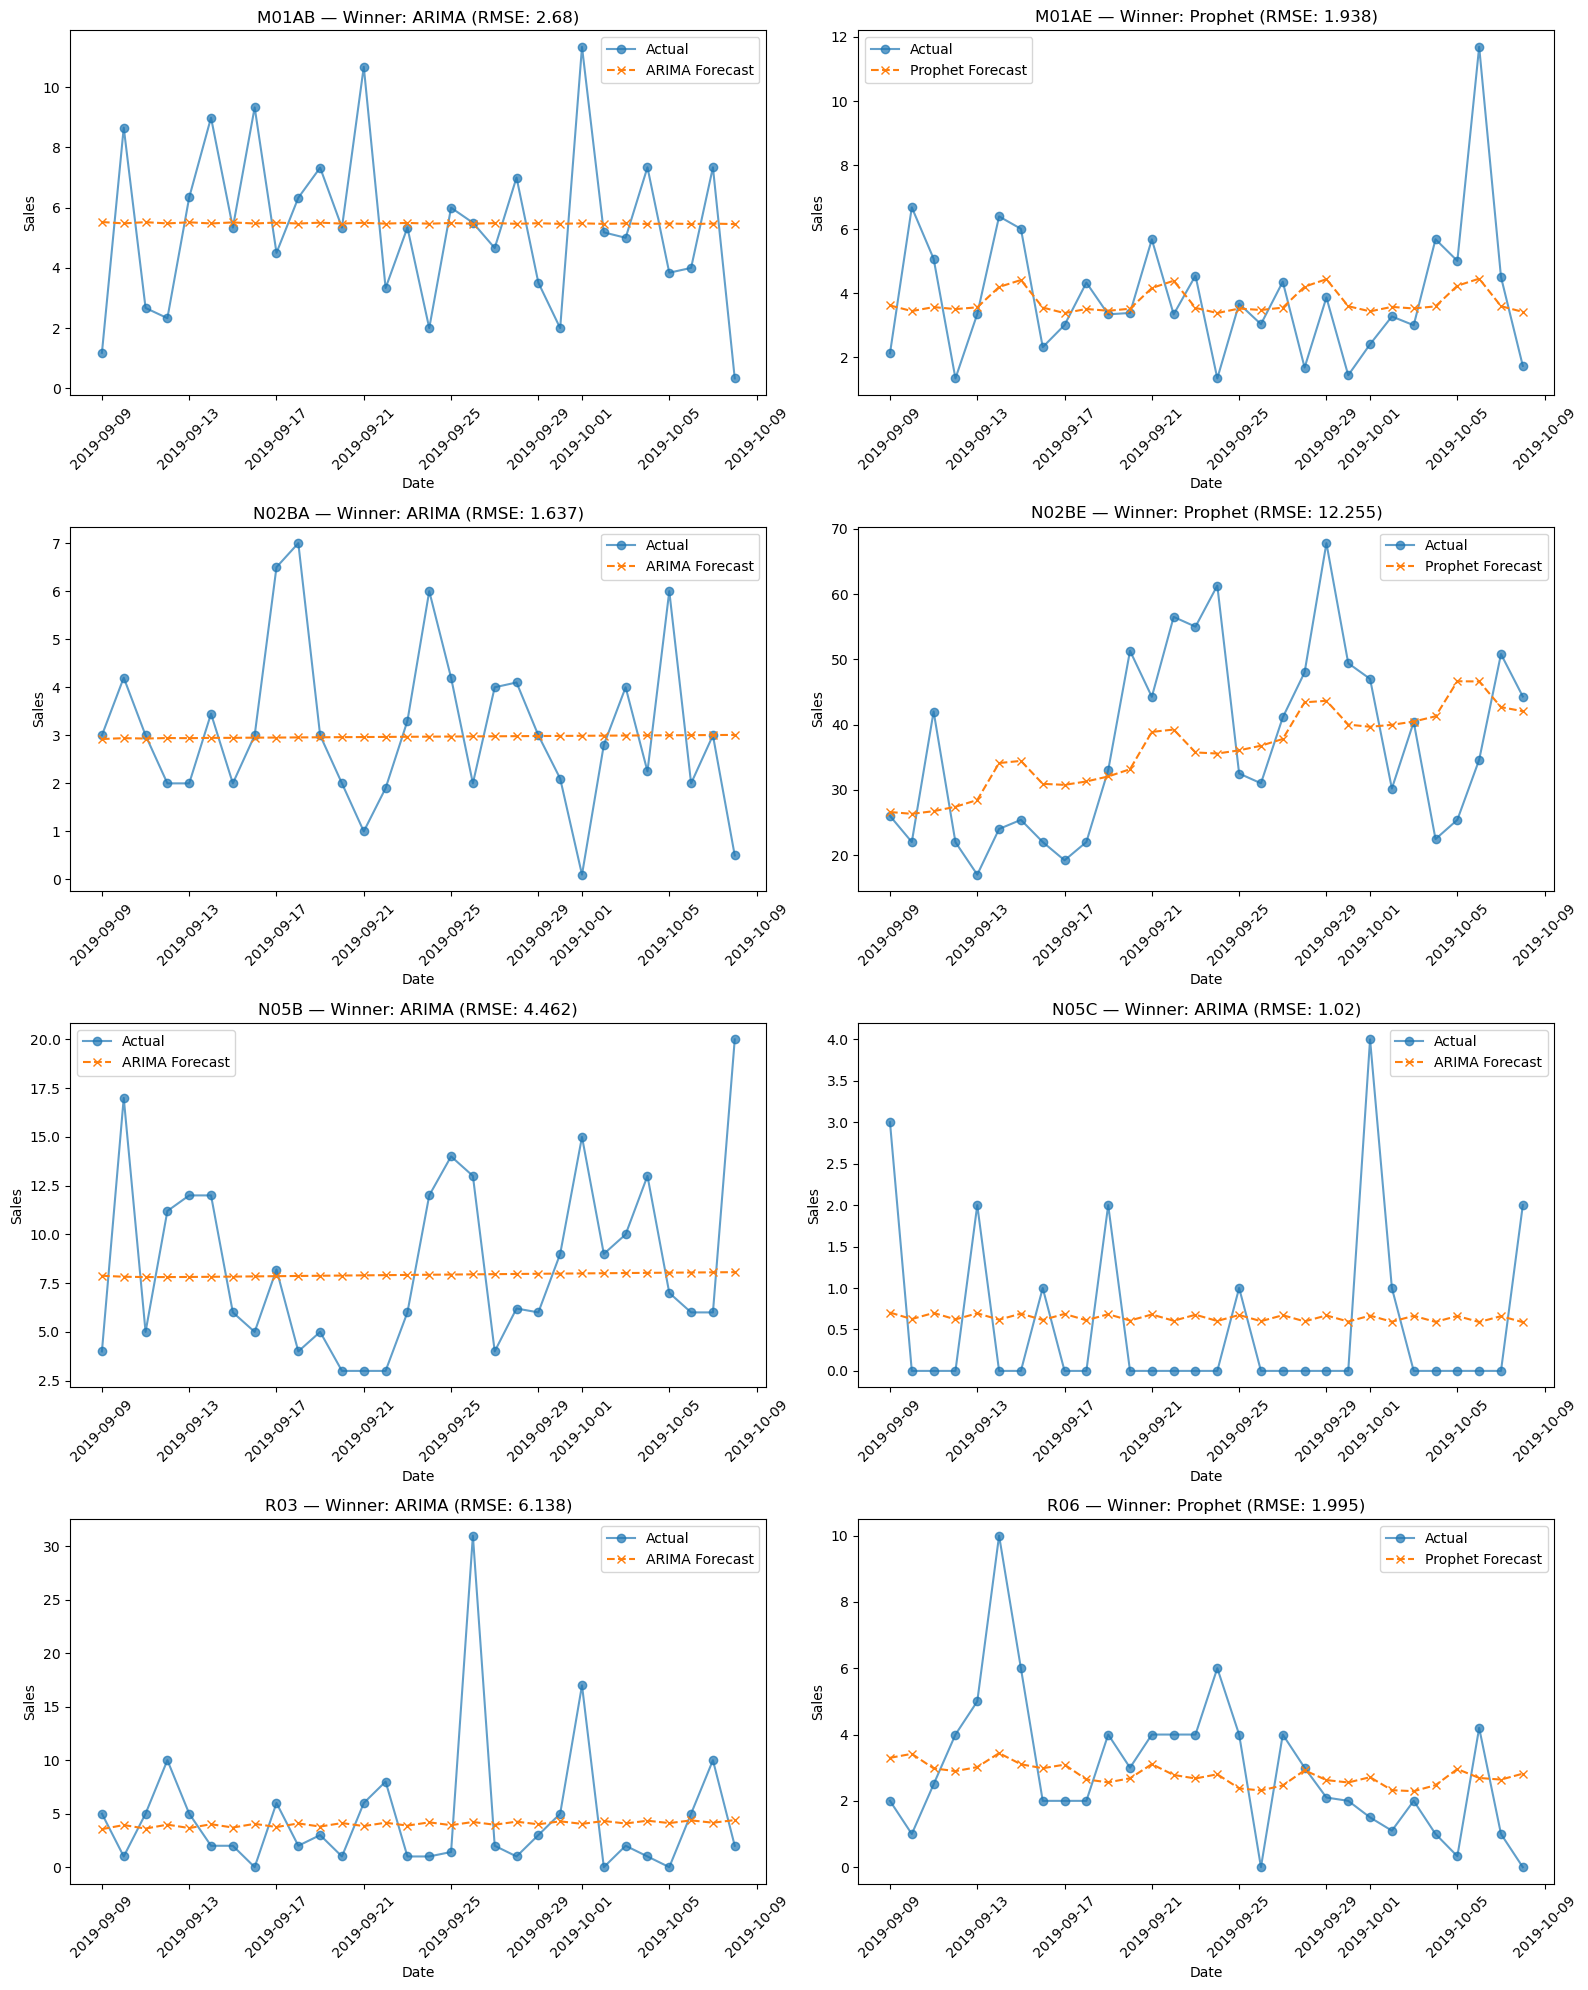

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, r in enumerate(results):
    axes[i].plot(r["test_dates"], r["test_actual"], label="Actual", marker="o", alpha=0.7)
    axes[i].plot(r["test_dates"], r["best_forecast"], label=f"{r["winner"]} Forecast", marker="x", linestyle="--")
    axes[i].set_title(f"{r['drug']} — Winner: {r['winner']} (RMSE: {r['best_rmse']})")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Sales")
    axes[i].legend()
    axes[i].tick_params(axis="x", rotation=45) 
plt.tight_layout()                                       
plt.savefig("forecast_comparison.png", dpi=150)         
plt.show()

In [7]:
import joblib
import os

os.makedirs("Model", exist_ok=True)                        

for r in results:                                          
    joblib.dump(r["arima_model"], f"Model/{r['drug']}_arima.pkl")      
    joblib.dump(r["prophet_model"], f"Model/{r['drug']}_prophet.pkl")  
    print(f"Saved models for {r['drug']}")

print("All models saved to Model/ folder!")

Saved models for M01AB
Saved models for M01AE
Saved models for N02BA
Saved models for N02BE
Saved models for N05B
Saved models for N05C
Saved models for R03
Saved models for R06
All models saved to Model/ folder!


In [8]:
import os

BASE_DIR = r"C:\Users\mukun\Drug_Demand_Forecaster"   # absolute path, no ambiguity

summary.to_csv(os.path.join(BASE_DIR, "model_comparison.csv"), index=False)
print("Saved!")

Saved!
